# Knot Propagator


A quick bit of code that recycles some of the aberrated knots stuff, but repurposes it to simulate the propagation of knots in hypothetically unaberrated conditions. Crucially, we now use the parameters defined for the mode sorter

In [93]:
import numpy as np 
from scipy.fft import fft2, ifft2, fftshift, ifftshift

import yaml 
from yaml import Loader
import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um
import os 

from optical_functions import cart2pol, setKnotType

import plotly
import plotly.graph_objs as go


# Some useful propagation functions from the AK code

# Fresnel Propagator Functions

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*0.25*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))
    
    
    return u2 

# After constructing the knot at z = 0, we use the Fresnel Propagator to evolve the knot
# Fresnel propagation using the Transfer function approach
# Based on Computational Fourier Optics by Voelz 
#
# PARAMETERS
# 
# Z0 - Z-propagation distance
# NZ - number of points
# AK - waist plane field to propagate
# maxx - Half length of the numerical window (w0)
# la (w0) - Wavelength of the simulated beam
# forwardProp -- determines if we are performing a forward propagation with the beam or not
# compress_len -- compressed n x n dimensionality that we actually save as a numpy file. 

def PropKnots(Z0,NZ,AK,maxx,la,forwardProp, compress_len):   
   # Propagation space
    Z=np.linspace(0,Z0,NZ)
    # Propagation steps
    dz=np.abs(Z[0]-Z[1])
    # Initialization the propagation 
    U=AK
    sim_len = len(U)
    
    # To refer to a square compress_len x compress_len array in the centre of the field, we invoke Field[compress_index:-compress_index, compress_index:-compress_index]
    compress_index = int((sim_len - compress_len)/2)
    print(f"Compression Index:{compress_index}")
    
    # Check that the oversampiling criterion value is less than dx, 
    # if it is greater, then we may run into artefacts
    M,nn=U.shape
    dx=(2*maxx)/M
    print(f"dx:{dx}")
    print(f"Oversampling criterion:{(la*dz)/(2*maxx)}") 
    
    # Forward Propagation 
    
    if (forwardProp):
        # Saving the field at every plane. Use compress_len to reduce memory usage
        F = np.zeros((NZ+1,compress_len,compress_len),dtype=complex)
        F[0] = AK[compress_index:-compress_index, compress_index:-compress_index]
        print(" INITIATING FORWARD PROPAGATION ")
        for ii in range(0,NZ):
            print(ii)
            U=propTF(U,2*maxx,la,dz) # Field at plane z->+z_0
            F[ii+1] = U[compress_index:-compress_index, compress_index:-compress_index]

        return F
    
    else: # Backwards propagation
        print(" INITIATING BACKWARD PROPAGATION ")
        U=AK
        FB = np.zeros((NZ,compress_len,compress_len),dtype=complex)
        for ii in range(0,NZ):
            print(ii)
            U=propTF(U,2*maxx,la,-dz) # Field at plane z->-z_0
            FB[ii] = U[compress_index:-compress_index, compress_index:-compress_index]
        return FB


'''
Computes the singularity points

F (SQUARE, complex array): The complete field whose singularity points we need to compute. NORMALIZE THIS, or the threshold variable won't work!!!!
A (boolean): indicates whether we are propagating forward or backwards
'''

def Singular2(F, A):
    
    X=[]
    Y=[]
    Z=[]
    leng = len(F[0]) # Pay attention to the size of your input array here 
    ll=np.arange(leng) 
    xf,yf=np.meshgrid(ll,ll)
    #JJ=np.sqrt((xf-(leng/2))**2+(yf-(leng/2))**2)>thresh

    for ii in range(0,len(F)):
        print(ii) 

        # Some of the contours become jittery enough that we don't end up collecting all of the intersection points. 
        # We apply a smoothing filter onto the contours to reduce the jittery-ness

        realF = np.real(F[ii])
        imF = np.imag(F[ii])

        contour1 = plt.contour(realF,0,colors='b');
        contour2 = plt.contour(imF,0,colors='r');
        xi = np.array([])
        yi = np.array([])
        for linecol in contour1.collections:
            for path in linecol.get_paths():
                for linecol2 in contour2.collections:
                    for path2 in linecol2.get_paths():
                        xinter, yinter = find_intersections(path.vertices, path2.vertices)
                        if (len(xinter) == len(yinter)):
                                  xi = np.append(xi, xinter)
                                  yi = np.append(yi, yinter)
                        else:
                                print(f"CRAPPY INTERSECTION DETECTED")
        X=np.concatenate((X,xi))
        Y=np.concatenate((Y,yi))
        if A==True:
            Z=np.concatenate((Z,ii*(xi*0+1)))
        else:
            Z=np.concatenate((Z,-ii*(xi*0+1)))
    return [X,Y,Z]


def find_intersections(A, B):
    #this function stolen from https://stackoverflow.com/questions/3252194/numpy-and-line-intersections#answer-9110966
    # min, max and all for arrays
    amin = lambda x1, x2: np.where(x1<x2, x1, x2)
    amax = lambda x1, x2: np.where(x1>x2, x1, x2)
    aall = lambda abools: np.dstack(abools).all(axis=2)
    slope = lambda line: (lambda d: d[:,1]/d[:,0])(np.diff(line, axis=0))

    x11, x21 = np.meshgrid(A[:-1, 0], B[:-1, 0])
    x12, x22 = np.meshgrid(A[1:, 0], B[1:, 0])
    y11, y21 = np.meshgrid(A[:-1, 1], B[:-1, 1])
    y12, y22 = np.meshgrid(A[1:, 1], B[1:, 1])

    m1, m2 = np.meshgrid(slope(A), slope(B))
    m1inv, m2inv = 1/m1, 1/m2

    yi = (m1*(x21-x11-m2inv*y21) + y11)/(1 - m1*m2inv)
    xi = (yi - y21)*m2inv + x21

    xconds = (amin(x11, x12) < xi, xi <= amax(x11, x12), 
              amin(x21, x22) < xi, xi <= amax(x21, x22) )
    yconds = (amin(y11, y12) < yi, yi <= amax(y11, y12),
              amin(y21, y22) < yi, yi <= amax(y21, y22) )

    return xi[aall(xconds)], yi[aall(yconds)]

'''
Makes a nice plot of the singularities.
Ord - singularity points 
zScale - scales the z-coordinate by a factor for plotting purposes
'''

def KnotPlot(Ord,zScale):
    # Configure the trace.
    trace = go.Scatter3d(
        x=Ord[0],  # <-- Put your data instead
        y=Ord[1],  # <-- Put your data instead
        z=Ord[2]*(zScale),  # <-- Put your data instead
        mode='markers',
        marker={
            'size': 3,
            'opacity': 0.8,})
    # Configure the layout.
    layout = go.Layout(margin={'l': 0, 'r': 0, 'b': 0, 't': 0})
    data = [trace]
    plot_figure = go.Figure(data=data, layout=layout)
    # Render the plot.
    plotly.offline.iplot(plot_figure)





Additional helper functions for plotting

In [94]:
# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()

load the configuration file and parameters

In [95]:
stream = open("configs/simKnot.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

knotType = cnfg['knotType'] # The type of knot to propagate 
shapeParams = cnfg['shapeParams'] # The shape parameters of our knot 
w0 = cnfg['w0']*mm # beam width of knot (in mm)
z0 = cnfg['z0']*cm # distance from z=0 cm by which we should propagate the knot (in the forwards and backwards directions)
nz = cnfg['nz'] # number of phase planes to "measure" within the propagation path 

initialize field

In [96]:
la=0.78*um 
k = (2*np.pi)/la
N=128
maxx = 20*um*N

# Space definition 
dx = maxx/N 
dy = maxx/N
h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)
xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

Create knot field at z=0 and plot intensity and phase of the field

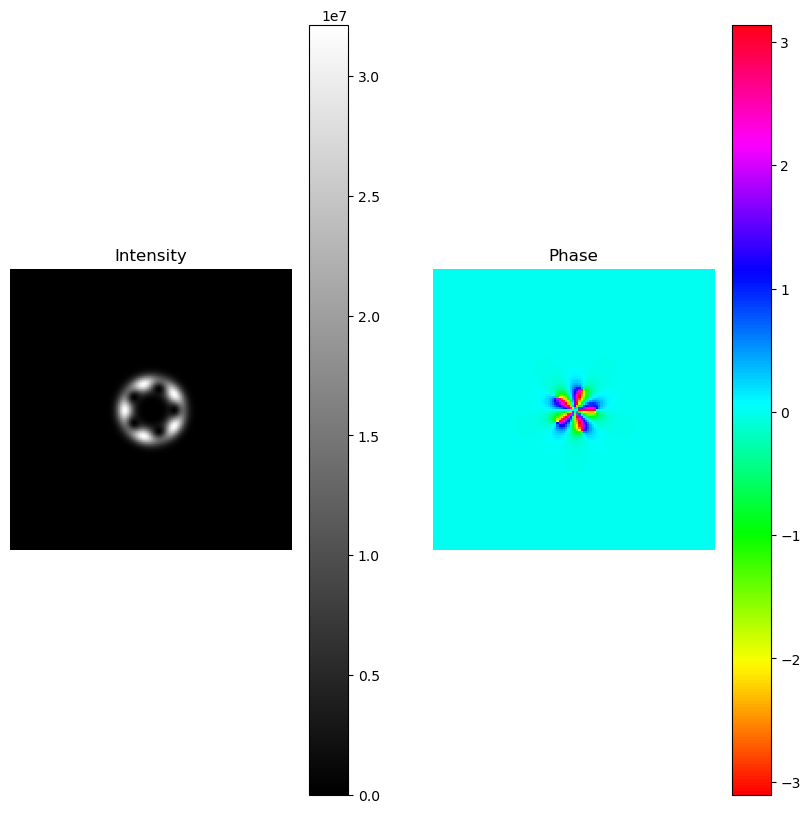

In [97]:
field = setKnotType(r, phi, w0, knotType, shapeParams)
TotInt(field)

Now propagate the knot up to a certain, pre-defined distance

Compression Index:32
dx:3.9999999999999996e-05
Oversampling criterion:2.4054276315789473e-06
 INITIATING BACKWARD PROPAGATION 
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
Compression Index:32
dx:3.9999999999999996e-05
Oversampling criterion:2.4054276315789473e-06
 INITIATING FORWARD PROPAGATION 
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


C:\Users\tjaou104\AppData\Local\Temp\ipykernel_25692\2594844791.py:167: RuntimeWarning:

divide by zero encountered in divide

C:\Users\tjaou104\AppData\Local\Temp\ipykernel_25692\2594844791.py:169: RuntimeWarning:

invalid value encountered in divide



22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


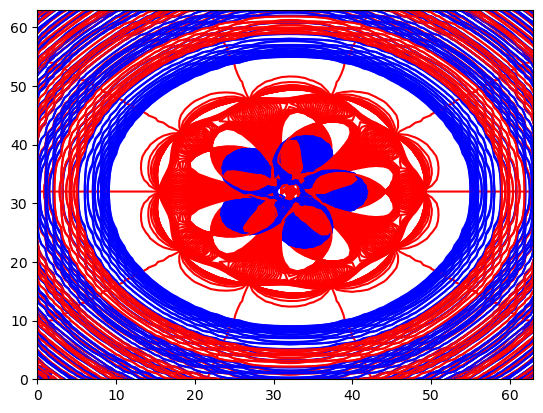

In [98]:
FB = PropKnots(z0, nz, field, maxx, la, False, compress_len=64) # Backwards propagation direction 
F = PropKnots(z0, nz, field, maxx, la, True, compress_len=64) # Forwards propagation direction 

# Swap the elements of the backwards propagating array s.t. the field at z=0 is at the end
temp = FB.copy()
for i in range(len(FB)):
    FB[i] = temp[len(FB)-1-i]

# Store forward/backwards propagated beams onto a single array. 
TP = np.concatenate((FB,F))

# Now compute and plot the singularities. The plotted singularities are scaled in the z-direction by a factor of 2 
sing = Singular2(TP,True)
KnotPlot(sing,2)